In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras import Model, layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

# Load Training Data
data_file = r'C:\Users\Liyuan\PycharmProjects\PycharmProjects\finetune training\train333.csv'  # Replace with your CSV file
data = pd.read_csv(data_file)

# Extract labels (y) from the first column and features (X) from the rest
y = data.iloc[:, 0].values  # The first column is the label
X = data.iloc[:, 1:].values  # All other columns are features

# Encode labels if they are not numerical
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Convert labels to one-hot encoding for multi-class classification
y_one_hot = to_categorical(y_encoded)

# Split data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X, y_one_hot, test_size=0.2, random_state=42)

In [2]:
# Reshape input data if it's image-like (e.g., CNN requires 3D inputs)
# Adjust this step as necessary based on your dataset
input_shape = (X_train.shape[1], 1)  # Example: reshape for 1D CNN
X_train = X_train.reshape(-1, *input_shape)
X_val = X_val.reshape(-1, *input_shape)

In [3]:
import tensorflow as tf
from tensorflow.keras.models import load_model, Model
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
import pandas as pd
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.regularizers import l2

# Assume `input_shape`, `X_train`, `y_train`, `X_val`, and `y_val` are defined elsewhere

# Load the pre-trained model
pretrained_model = load_model('newtrainedCNN.h5')  # Replace with your .h5 model file

# Freeze all layers in the pre-trained model
for layer in pretrained_model.layers:
    layer.trainable = False

# Define the input layer for the new model
new_input = layers.Input(shape=input_shape)

# Pass the input through the pre-trained model
x = pretrained_model(new_input)

# Add custom layers for fine-tuning
x = layers.Dense(128, activation='relu', kernel_regularizer=l2(0.02))(x)  # Increased L2 regularization
x = layers.Dropout(0.6)(x)  # Increased dropout rate
x = layers.Dense(64, activation='relu', kernel_regularizer=l2(0.01))(x)  # Add another dense layer with L2
x = layers.Dropout(0.5)(x)  # Additional dropout for regularization
predictions = layers.Dense(2, activation='softmax')(x)  # Two output neurons for two classes


fine_tuned_model = Model(inputs=new_input, outputs=predictions)

# Compile the fine-tuned model with categorical cross-entropy
fine_tuned_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Ensure labels are one-hot encoded
# Example: Convert y_train and y_val to one-hot if not already one-hot encoded
num_classes = 2  # Update with the number of classes
if len(y_train.shape) == 1:  # If labels are not one-hot encoded
    y_train = to_categorical(y_train, num_classes=num_classes)
    y_val = to_categorical(y_val, num_classes=num_classes)

# Train the fine-tuned model
history = fine_tuned_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    verbose=1
)

# Save the fine-tuned model
fine_tuned_model.save('fine_tuned_model.h5')
print("Fine-tuned model saved as 'fine_tuned_model.h5'.")

# Evaluate the model
loss, accuracy = fine_tuned_model.evaluate(X_val, y_val, verbose=0)
print(f"Validation Accuracy: {accuracy:.4f}")


Epoch 1/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 8s 49ms/step - accuracy: 0.5259 - loss: 1.9284 - val_accuracy: 0.9566 - val_loss: 1.8105
Epoch 2/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - accuracy: 0.6689 - loss: 1.8009 - val_accuracy: 0.9614 - val_loss: 1.6895
Epoch 3/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - accuracy: 0.7926 - loss: 1.6806 - val_accuracy: 0.9542 - val_loss: 1.5724
Epoch 4/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.8360 - loss: 1.5742 - val_accuracy: 0.9494 - val_loss: 1.4601
Epoch 5/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.8622 - loss: 1.4794 - val_accuracy: 0.9398 - val_loss: 1.3534
Epoch 6/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 0.8758 - loss: 1.3850 - val_accuracy: 0.9470 - val_loss: 1.2548
Epoch 7/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - accuracy: 0.8966 - loss: 1.2895 - val_accuracy: 0.9470 - val_loss: 1.1640
Epoch 8/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 0.9014 - loss: 1.1960 - val_accuracy: 0.9470 - v

Fine-tuned model saved as 'fine_tuned_model.h5'.
Validation Accuracy: 0.9590


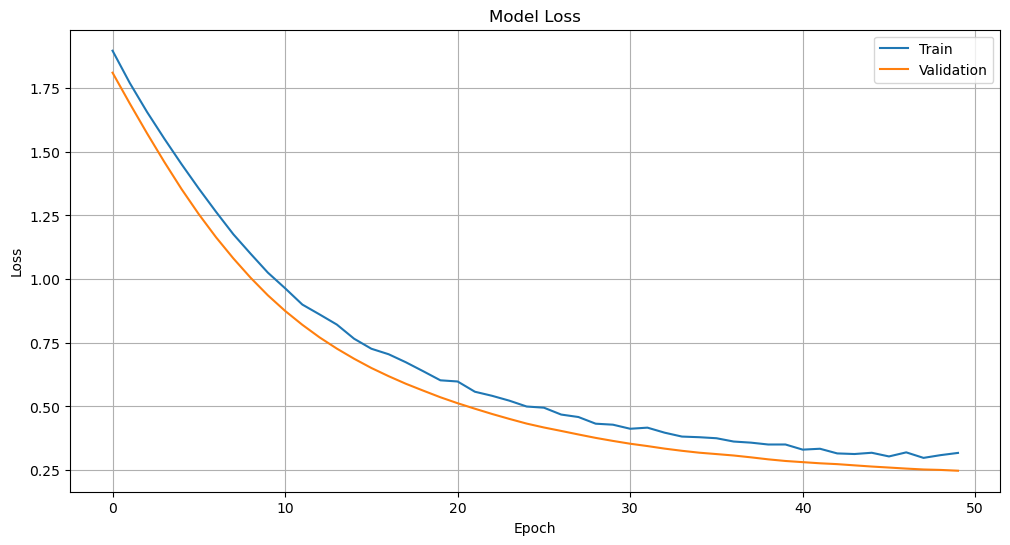

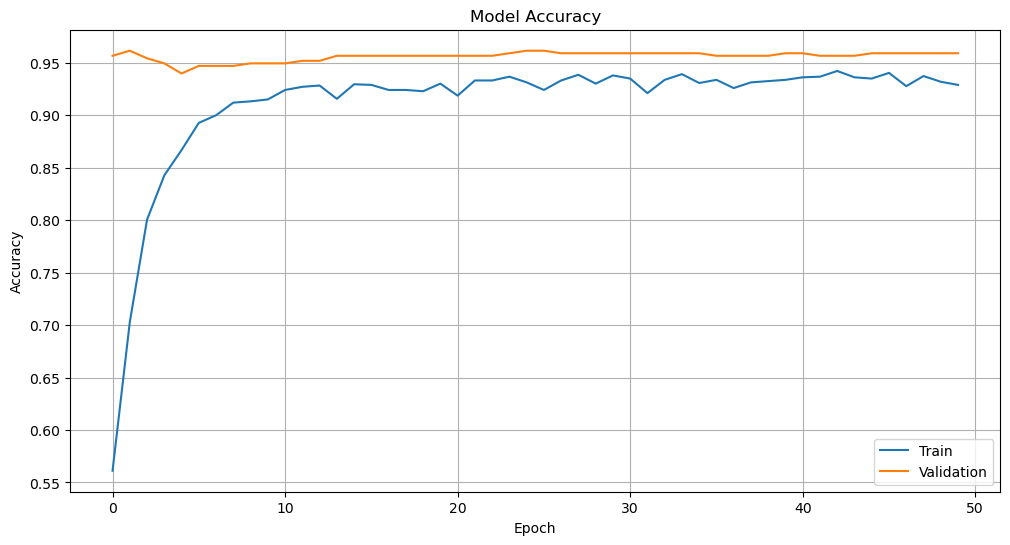

In [4]:
# Now, let's plot the training and validation loss
import matplotlib.pyplot as plt

# Plot training & validation loss values
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper right')
plt.grid(True)
plt.show()

# If you want to plot accuracy as well
plt.figure(figsize=(12, 6))
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='lower right')
plt.grid(True)
plt.show()

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step


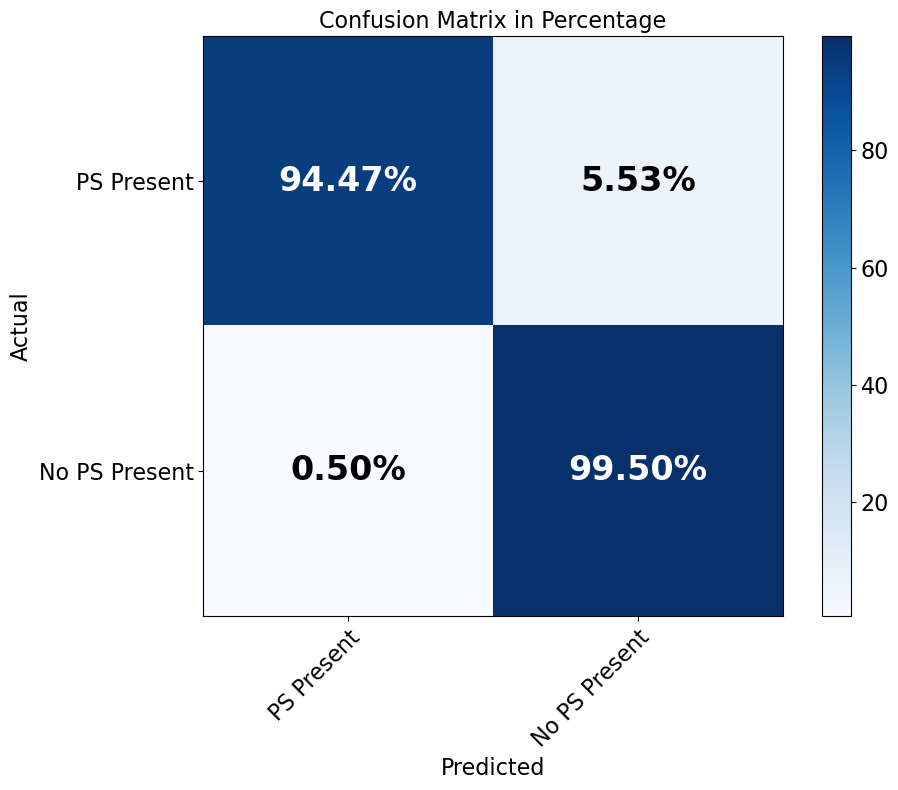

In [2]:
# plot confusion matrix

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# Load the test data (replace 'test_data.csv' with your file)
test_data = pd.read_csv(r'C:\Users\Liyuan\PycharmProjects\PycharmProjects\finetuneblindtest\test333.csv')

# Assuming the first column contains labels and the rest are features
y_test = test_data.iloc[:, 0].values  # Extract labels
X_test = test_data.iloc[:, 1:].values  # Extract features

# Reshape features to match the input shape of the model
X_test = X_test.reshape(-1, X_test.shape[1], 1)  # Adjust shape as necessary

# Load the trained model
model = load_model('fine_tuned_model.h5')

# Predict probabilities for each class
y_pred_probs = model.predict(X_test)

# Convert predicted probabilities to class labels
y_pred = np.argmax(y_pred_probs, axis=1)

# Ensure y_test is in integer format (convert from one-hot if necessary)
if len(y_test.shape) > 1:  # If y_test is one-hot encoded
    y_test = np.argmax(y_test, axis=1)


# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Swap the order of labels: "PS Present" (now index 0) and "No PS Present" (index 1)
cm = cm[[1, 0], :]  # Swap rows
cm = cm[:, [1, 0]]  # Swap columns

# Convert counts to percentages
cm_percentage = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

# Define labels
labels = ["PS Present", "No PS Present"]

# Plot confusion matrix
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(cm_percentage, interpolation='nearest', cmap='Blues')
cbar = ax.figure.colorbar(im, ax=ax)

# Set custom font sizes
title_fontsize = 16
label_fontsize = 16
tick_fontsize = 16
cbar.ax.tick_params(labelsize=16)  # Adjust font size of scale bar numbers

# Set title and axis labels
ax.set_title("Confusion Matrix in Percentage", fontsize=title_fontsize)
ax.set_xlabel("Predicted", fontsize=label_fontsize)
ax.set_ylabel("Actual", fontsize=label_fontsize)

# Show all ticks and label them
ax.set(xticks=np.arange(cm.shape[1]),
       yticks=np.arange(cm.shape[0]),
       xticklabels=labels, yticklabels=labels)

# Rotate the tick labels and set their font size
plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor", fontsize=tick_fontsize)
plt.setp(ax.get_yticklabels(), fontsize=tick_fontsize)

# Loop over data dimensions and create text annotations
fmt = ".2f"  # Format for percentages
thresh = cm_percentage.max() / 2.  # Threshold for text color
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, format(cm_percentage[i, j], fmt) + '%',
                ha="center", va="center",
                color="white" if cm_percentage[i, j] > thresh else "black",fontsize=24, fontweight='bold')

plt.tight_layout()
plt.show()

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step


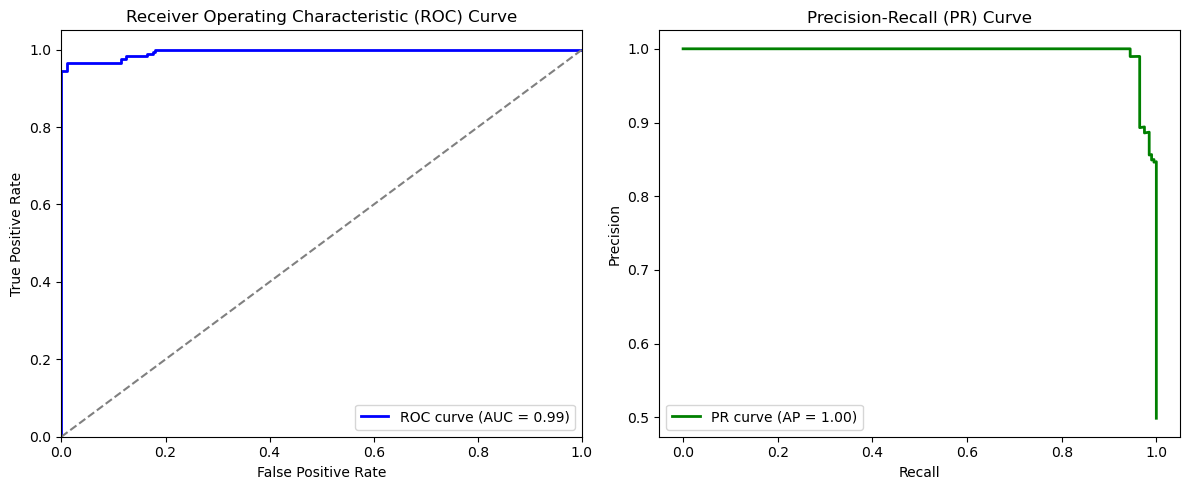

In [7]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
import numpy as np
import pandas as pd
from tensorflow.keras.models import load_model
from sklearn.metrics import confusion_matrix

# Function to plot ROC and PR curves
def plot_roc_pr_curves(y_true, y_scores):
    # ROC Curve
    fpr, tpr, _ = roc_curve(y_true, y_scores)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='grey', linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend(loc='lower right')

    # Precision-Recall Curve
    precision, recall, _ = precision_recall_curve(y_true, y_scores)
    avg_precision = average_precision_score(y_true, y_scores)

    plt.subplot(1, 2, 2)
    plt.plot(recall, precision, color='green', lw=2, label=f'PR curve (AP = {avg_precision:.2f})')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall (PR) Curve')
    plt.legend(loc='lower left')

    plt.tight_layout()
    plt.show()

# Load the test data (replace 'test_data.csv' with your file)
test_data = pd.read_csv(r'C:\Users\Liyuan\PycharmProjects\PycharmProjects\finetuneblindtest\test333.csv')

# Assuming the first column contains labels and the rest are features
y_test = test_data.iloc[:, 0].values  # Extract labels
X_test = test_data.iloc[:, 1:].values  # Extract features

# Reshape features to match the input shape of the model
X_test = X_test.reshape(-1, X_test.shape[1], 1)  # Adjust shape as necessary

# Load the trained model
model = load_model('fine_tuned_model.h5')

# Predict probabilities for each class
y_pred_probs = model.predict(X_test)

# Extract the probability for the positive class (assuming binary classification)
y_scores = y_pred_probs[:, 1]

# Ensure y_test is in integer format (convert from one-hot if necessary)
if len(y_test.shape) > 1:  # If y_test is one-hot encoded
    y_test = np.argmax(y_test, axis=1)

# Plot ROC and PR curves
plot_roc_pr_curves(y_test, y_scores)
